<a href="https://colab.research.google.com/github/septianapraditama-dev/Daya-Beli/blob/feature-lp2-septiana/gruwithpriceandump.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mount Google Drive & Import Library


Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import Library

In [2]:
# Manajemen data
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & evaluasi
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Baseline models
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

# Biar gak kepotong tampilannya
pd.set_option('display.max_columns', None)

print("✅ Library berhasil diimport")
print("🎉 TensorFlow version:", tf.__version__)

✅ Library berhasil diimport
🎉 TensorFlow version: 2.19.0


Cek Ketersediaan File

In [3]:
import os

# Path ke folder Capstone (sesuaikan kalau beda)
base_path = "/content/drive/MyDrive/Capstone/"

# Lihat daftar file di folder
print("File dalam folder Capstone:")
print(os.listdir(base_path))

File dalam folder Capstone:
['ump_dki_jakarta_daily_clean.csv', 'ump_dki_jakarta_daily_clean.gsheet', 'prices_daily_tidy_clean.csv']


# Load dan Gabung 2 Dataset (Price + UMP)

Load Data

In [7]:
# Load dataset Price
df_price = pd.read_csv(base_path + "prices_daily_tidy_clean.csv")

# Load dataset UMP
df_ump = pd.read_csv(base_path + "ump_dki_jakarta_daily_clean.csv")

# Cek 5 baris pertama masing-masing
print("📊 PRICE DATA:")
display(df_price.head())

print("\n📊 UMP DATA:")
display(df_ump.head())

📊 PRICE DATA:


,tanggal,region,komoditas,harga,harga_is_outlier,harga_is_imputed
0,2024-01-01,Jakarta Barat,ayam_ras,38750.0,0,0
1,2024-01-02,Jakarta Barat,ayam_ras,39429.0,0,0
2,2024-01-03,Jakarta Barat,ayam_ras,39571.0,0,0
3,2024-01-04,Jakarta Barat,ayam_ras,38667.0,0,0
4,2024-01-05,Jakarta Barat,ayam_ras,40000.0,0,0



📊 UMP DATA:


,tanggal,region,ump_daily,ump
0,2024-01-01,Jakarta Barat,163463.903226,5067381.0
1,2024-01-02,Jakarta Barat,163463.903226,5067381.0
2,2024-01-03,Jakarta Barat,163463.903226,5067381.0
3,2024-01-04,Jakarta Barat,163463.903226,5067381.0
4,2024-01-05,Jakarta Barat,163463.903226,5067381.0


Gabung Dataset

In [8]:
# Konversi tanggal ke datetime
df_price['tanggal'] = pd.to_datetime(df_price['tanggal'])
df_ump['tanggal'] = pd.to_datetime(df_ump['tanggal'])

# Gabungkan kedua dataset berdasarkan tanggal dan region
df_merged = pd.merge(
    df_price,
    df_ump,
    on=['tanggal', 'region'],
    how='inner'
)

print(f"\n✅ Data setelah digabung: {df_merged.shape[0]} baris, {df_merged.shape[1]} kolom")
display(df_merged.head())

# Cek data kosong
print("\n🔍 Cek missing values:")
print(df_merged.isnull().sum())

# Simpan file gabungan
df_merged.to_csv(base_path + "price_ump_merged.csv", index=False)
print("✅ File gabungan disimpan sebagai 'price_ump_merged.csv'")


✅ Data setelah digabung: 36550 baris, 8 kolom


,tanggal,region,komoditas,harga,harga_is_outlier,harga_is_imputed,ump_daily,ump
0,2024-01-01,Jakarta Barat,ayam_ras,38750.0,0,0,163463.903226,5067381.0
1,2024-01-02,Jakarta Barat,ayam_ras,39429.0,0,0,163463.903226,5067381.0
2,2024-01-03,Jakarta Barat,ayam_ras,39571.0,0,0,163463.903226,5067381.0
3,2024-01-04,Jakarta Barat,ayam_ras,38667.0,0,0,163463.903226,5067381.0
4,2024-01-05,Jakarta Barat,ayam_ras,40000.0,0,0,163463.903226,5067381.0



🔍 Cek missing values:
tanggal             0
region              0
komoditas           0
harga               0
harga_is_outlier    0
harga_is_imputed    0
ump_daily           0
ump                 0
dtype: int64
✅ File gabungan disimpan sebagai 'price_ump_merged.csv'


# Eksplorasi Data (EDA)

Info Dataset Gabungan

In [9]:
# Info dasar dataset gabungan
print("📋 INFO DATASET GABUNGAN:")
print(df_merged.info())
print("\n📊 STATISTIK DESKRIPTIF:")
display(df_merged.describe())

# Cek rentang waktu
print("📅 Rentang tanggal:")
print("Dari:", df_merged['tanggal'].min())
print("Sampai:", df_merged['tanggal'].max())
print("Total hari:", (df_merged['tanggal'].max() - df_merged['tanggal'].min()).days)

#Cek unique Values
print("🏙️ Region yang ada:")
print(df_merged['region'].unique())

print("\n🛒 Komoditas yang ada:")
print(df_merged['komoditas'].unique())
print("Jumlah komoditas:", df_merged['komoditas'].nunique())

print("\n📆 Tahun yang ada:")
print(df_merged['tanggal'].dt.year.unique())

📋 INFO DATASET GABUNGAN:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36550 entries, 0 to 36549
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   tanggal           36550 non-null  datetime64[ns]
 1   region            36550 non-null  object        
 2   komoditas         36550 non-null  object        
 3   harga             36550 non-null  float64       
 4   harga_is_outlier  36550 non-null  int64         
 5   harga_is_imputed  36550 non-null  int64         
 6   ump_daily         36550 non-null  float64       
 7   ump               36550 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(2)
memory usage: 2.2+ MB
None

📊 STATISTIK DESKRIPTIF:


,tanggal,harga,harga_is_outlier,harga_is_imputed,ump_daily,ump
count,36550,36550.000000,36550.000000,36550.000000,36550.000000,3.655000e+04
mean,2024-12-31 00:00:00.000000256,46797.562982,0.024870,0.088263,171777.980848,5.231846e+06
min,2024-01-01 00:00:00,7325.000000,0.000000,0.000000,163463.903226,5.067381e+06
25%,2024-07-01 00:00:00,18203.500000,0.000000,0.000000,163463.903226,5.067381e+06
50%,2024-12-31 00:00:00,40000.000000,0.000000,0.000000,174089.064516,5.067381e+06
75%,2025-07-02 00:00:00,51667.000000,0.000000,0.000000,174089.064516,5.396761e+06
max,2025-12-31 00:00:00,182778.000000,1.000000,1.000000,192741.464286,5.396761e+06
std,NaN,35655.281166,0.155731,0.283680,7172.366196,1.646921e+05


📅 Rentang tanggal:
Dari: 2024-01-01 00:00:00
Sampai: 2025-12-31 00:00:00
Total hari: 730
🏙️ Region yang ada:
['Jakarta Barat' 'Jakarta Pusat' 'Jakarta Selatan' 'Jakarta Timur'
 'Jakarta Utara']

🛒 Komoditas yang ada:
['ayam_ras' 'bawang_merah' 'bawang_putih' 'beras_medium'
 'beras_setra_premium' 'cabai_merah_keriting' 'cabai_rawit_merah'
 'daging_sapi_murni' 'gula_pasir' 'telur_ayam_ras']
Jumlah komoditas: 10

📆 Tahun yang ada:
[2024 2025]


Visualisasi tren harga komoditas utama

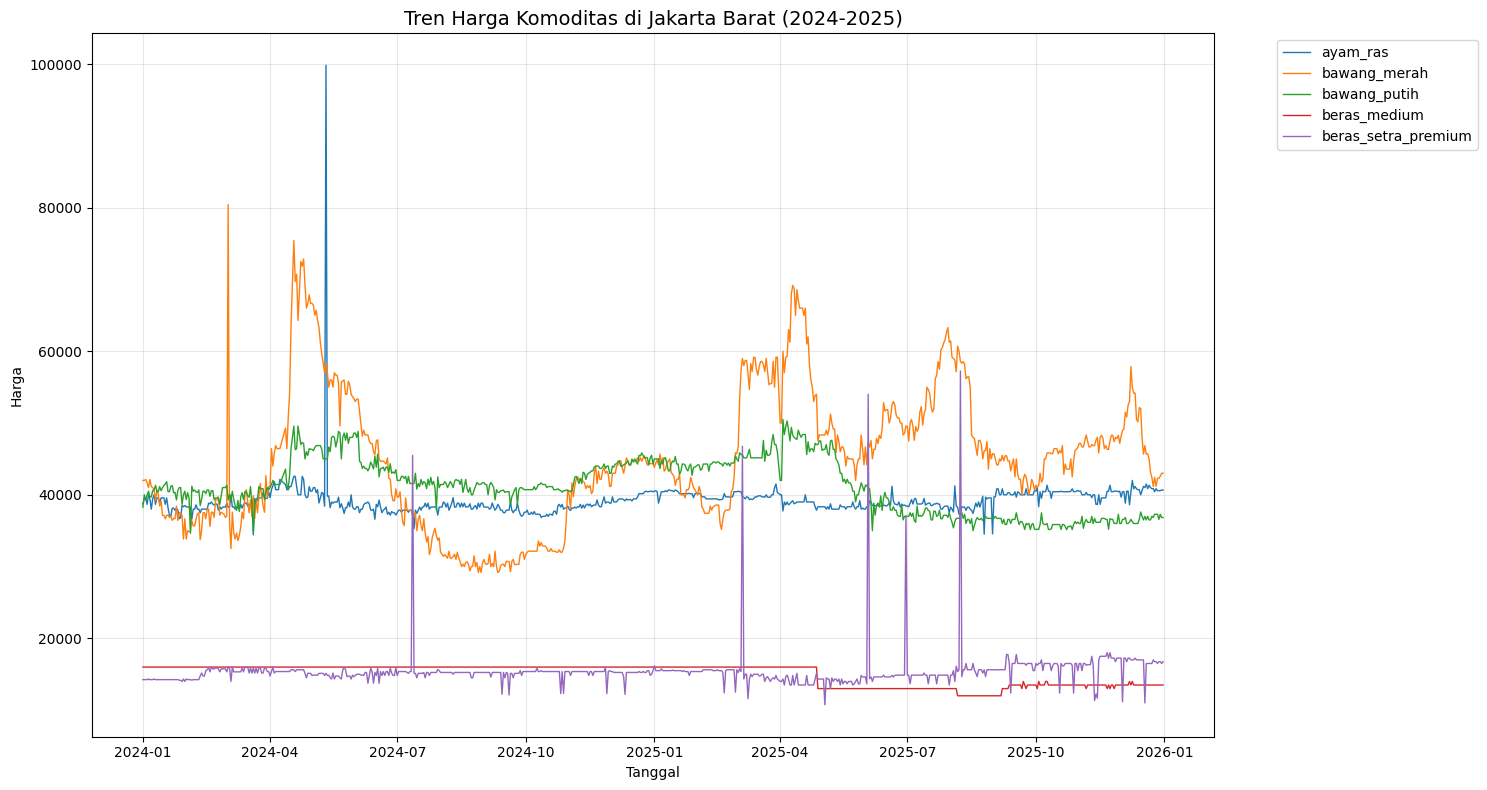

In [10]:
# Pilih 5 komoditas pertama sebagai sample
komoditas_sample = df_merged['komoditas'].unique()[:5]

plt.figure(figsize=(15, 8))

for komoditas in komoditas_sample:
    data_komoditas = df_merged[df_merged['komoditas'] == komoditas]
    # Ambil 1 region sebagai sample (Jakarta Barat)
    data_region = data_komoditas[data_komoditas['region'] == 'Jakarta Barat']
    plt.plot(data_region['tanggal'], data_region['harga'], label=komoditas, linewidth=1)

plt.title('Tren Harga Komoditas di Jakarta Barat (2024-2025)', fontsize=14)
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Cek distribusi harga per komoditas

<Figure size 1200x600 with 0 Axes>

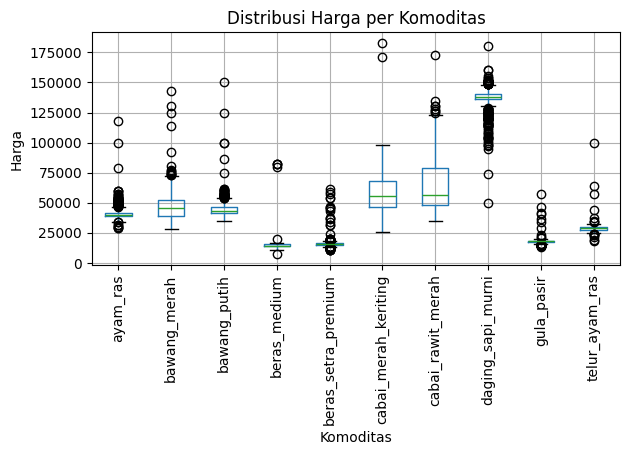

In [11]:
plt.figure(figsize=(12, 6))
df_merged.boxplot(column='harga', by='komoditas', rot=90)
plt.title('Distribusi Harga per Komoditas')
plt.suptitle('')
plt.xlabel('Komoditas')
plt.ylabel('Harga')
plt.tight_layout()
plt.show()

Cek pola UMP per region

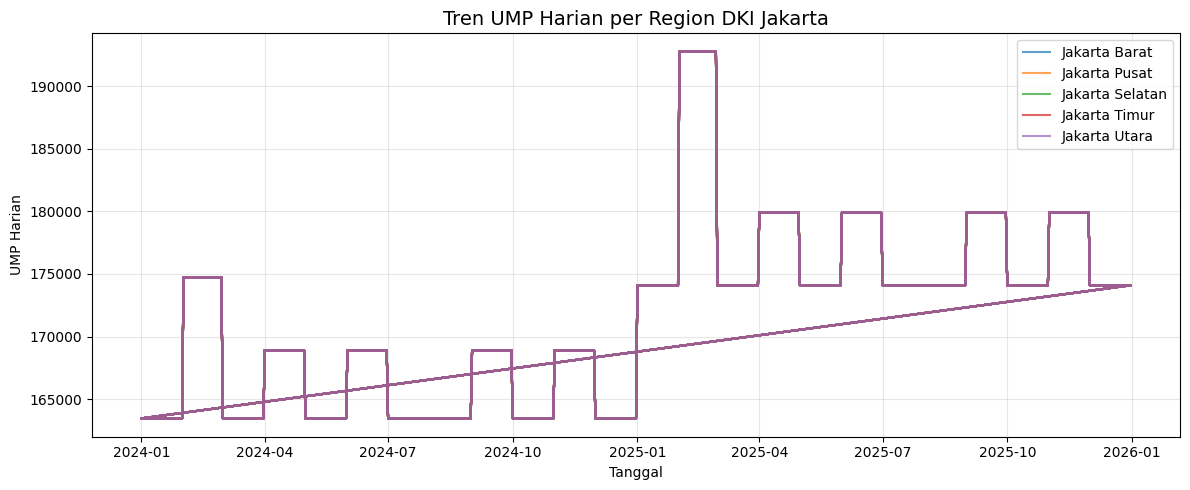

In [12]:
plt.figure(figsize=(12, 5))
for region in df_merged['region'].unique():
    data_region = df_merged[df_merged['region'] == region]
    plt.plot(data_region['tanggal'], data_region['ump_daily'], label=region, alpha=0.7)

plt.title('Tren UMP Harian per Region DKI Jakarta', fontsize=14)
plt.xlabel('Tanggal')
plt.ylabel('UMP Harian')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Cek korelasi sederhana (harga vs UMP)

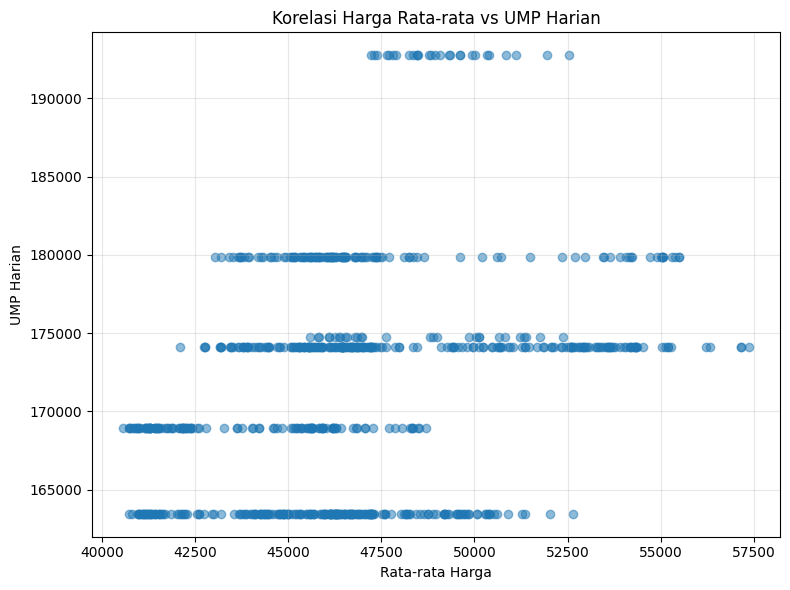

📊 Korelasi harga vs UMP: 0.330


In [13]:
# Hitung rata-rata harga per hari untuk melihat korelasi dengan UMP
df_daily_avg = df_merged.groupby('tanggal').agg({
    'harga': 'mean',
    'ump_daily': 'mean'
}).reset_index()

# Plot scatter
plt.figure(figsize=(8, 6))
plt.scatter(df_daily_avg['harga'], df_daily_avg['ump_daily'], alpha=0.5)
plt.title('Korelasi Harga Rata-rata vs UMP Harian')
plt.xlabel('Rata-rata Harga')
plt.ylabel('UMP Harian')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Hitung korelasi
correlation = df_daily_avg['harga'].corr(df_daily_avg['ump_daily'])
print(f"📊 Korelasi harga vs UMP: {correlation:.3f}")

# Feature Engineering

In [14]:
# Urutkan berdasarkan region, komoditas, tanggal (PENTING!)
df_merged = df_merged.sort_values(['region', 'komoditas', 'tanggal']).reset_index(drop=True)

print("✅ Data terurut:")
print(df_merged[['region', 'komoditas', 'tanggal', 'harga']].head(10))

✅ Data terurut:
          region komoditas    tanggal    harga
0  Jakarta Barat  ayam_ras 2024-01-01  38750.0
1  Jakarta Barat  ayam_ras 2024-01-02  39429.0
2  Jakarta Barat  ayam_ras 2024-01-03  39571.0
3  Jakarta Barat  ayam_ras 2024-01-04  38667.0
4  Jakarta Barat  ayam_ras 2024-01-05  40000.0
5  Jakarta Barat  ayam_ras 2024-01-06  39429.0
6  Jakarta Barat  ayam_ras 2024-01-07  38000.0
7  Jakarta Barat  ayam_ras 2024-01-08  39429.0
8  Jakarta Barat  ayam_ras 2024-01-09  40000.0
9  Jakarta Barat  ayam_ras 2024-01-10  38667.0


Lag Features

In [15]:
# Buat lag features (1, 2, 3, 7, 30 hari)
for lag in [1, 2, 3, 7, 30]:
    df_merged[f'harga_lag_{lag}'] = df_merged.groupby(['region', 'komoditas'])['harga'].shift(lag)
    df_merged[f'ump_lag_{lag}'] = df_merged.groupby(['region'])['ump_daily'].shift(lag)

print("✅ Lag features selesai")
print(df_merged[[col for col in df_merged.columns if 'lag' in col]].head())

✅ Lag features selesai
   harga_lag_1      ump_lag_1  harga_lag_2      ump_lag_2  harga_lag_3  \
0          NaN            NaN          NaN            NaN          NaN   
1      38750.0  163463.903226          NaN            NaN          NaN   
2      39429.0  163463.903226      38750.0  163463.903226          NaN   
3      39571.0  163463.903226      39429.0  163463.903226      38750.0   
4      38667.0  163463.903226      39571.0  163463.903226      39429.0   

       ump_lag_3  harga_lag_7  ump_lag_7  harga_lag_30  ump_lag_30  
0            NaN          NaN        NaN           NaN         NaN  
1            NaN          NaN        NaN           NaN         NaN  
2            NaN          NaN        NaN           NaN         NaN  
3  163463.903226          NaN        NaN           NaN         NaN  
4  163463.903226          NaN        NaN           NaN         NaN  


Moving Average

In [16]:
# Moving average untuk harga (3, 7, 14, 30 hari)
for window in [3, 7, 14, 30]:
    df_merged[f'harga_ma_{window}'] = df_merged.groupby(['region', 'komoditas'])['harga'].transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )

# Moving average untuk UMP
for window in [7, 30]:
    df_merged[f'ump_ma_{window}'] = df_merged.groupby(['region'])['ump_daily'].transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )

print("✅ Moving average selesai")

✅ Moving average selesai


Rolling Statistics

In [17]:
# Rolling statistics untuk harga (std, min, max)
for window in [7, 14, 30]:
    df_merged[f'harga_std_{window}'] = df_merged.groupby(['region', 'komoditas'])['harga'].transform(
        lambda x: x.rolling(window, min_periods=1).std()
    )
    df_merged[f'harga_min_{window}'] = df_merged.groupby(['region', 'komoditas'])['harga'].transform(
        lambda x: x.rolling(window, min_periods=1).min()
    )
    df_merged[f'harga_max_{window}'] = df_merged.groupby(['region', 'komoditas'])['harga'].transform(
        lambda x: x.rolling(window, min_periods=1).max()
    )

print("✅ Rolling statistics selesai")

✅ Rolling statistics selesai


Indikator Musiman

In [18]:
# Ekstrak dari kolom tanggal
df_merged['year'] = df_merged['tanggal'].dt.year
df_merged['month'] = df_merged['tanggal'].dt.month
df_merged['day'] = df_merged['tanggal'].dt.day
df_merged['dayofweek'] = df_merged['tanggal'].dt.dayofweek  # 0=Senin, 6=Minggu
df_merged['quarter'] = df_merged['tanggal'].dt.quarter

# Binary features
df_merged['is_weekend'] = (df_merged['dayofweek'] >= 5).astype(int)
df_merged['is_month_start'] = df_merged['tanggal'].dt.is_month_start.astype(int)
df_merged['is_month_end'] = df_merged['tanggal'].dt.is_month_end.astype(int)

print("✅ Indikator musiman selesai")

✅ Indikator musiman selesai


Fitur Interaksi (Harga vs UMP)

In [19]:
# Rasio harga terhadap UMP (semakin besar = semakin mahal relatif terhadap upah)
df_merged['rasio_harga_ump'] = df_merged['harga'] / df_merged['ump_daily']

# Selisih harga vs moving average (indikator momentum)
df_merged['harga_vs_ma7'] = df_merged['harga'] - df_merged['harga_ma_7']
df_merged['harga_vs_ma30'] = df_merged['harga'] - df_merged['harga_ma_30']

print("✅ Fitur interaksi selesai")

✅ Fitur interaksi selesai


Cek Hasil Akhir & Simpan

In [20]:
#Cek Hasil
print(f"📊 Jumlah fitur sekarang: {df_merged.shape[1]} kolom")
print("\n🔍 5 baris pertama:")
display(df_merged.head())

# Lihat daftar kolom baru
new_features = [col for col in df_merged.columns if col not in ['tanggal', 'region', 'komoditas',
                                                                 'harga', 'ump_daily', 'ump',
                                                                 'harga_is_outlier', 'harga_is_imputed']]
print(f"\n✅ Fitur baru yang dibuat ({len(new_features)} fitur):")
print(new_features)

# Simpan ke Drive
df_merged.to_csv(base_path + "price_ump_with_features.csv", index=False)
print("✅ Data dengan fitur disimpan sebagai 'price_ump_with_features.csv'")

📊 Jumlah fitur sekarang: 44 kolom

🔍 5 baris pertama:


,tanggal,region,komoditas,harga,harga_is_outlier,harga_is_imputed,ump_daily,ump,harga_lag_1,ump_lag_1,harga_lag_2,ump_lag_2,harga_lag_3,ump_lag_3,harga_lag_7,ump_lag_7,harga_lag_30,ump_lag_30,harga_ma_3,harga_ma_7,harga_ma_14,harga_ma_30,ump_ma_7,ump_ma_30,harga_std_7,harga_min_7,harga_max_7,harga_std_14,harga_min_14,harga_max_14,harga_std_30,harga_min_30,harga_max_30,year,month,day,dayofweek,quarter,is_weekend,is_month_start,is_month_end,rasio_harga_ump,harga_vs_ma7,harga_vs_ma30
0,2024-01-01,Jakarta Barat,ayam_ras,38750.0,0,0,163463.903226,5067381.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38750.000000,38750.00,38750.00,38750.00,163463.903226,163463.903226,NaN,38750.0,38750.0,NaN,38750.0,38750.0,NaN,38750.0,38750.0,2024,1,1,0,1,0,1,0,0.237055,0.00,0.00
1,2024-01-02,Jakarta Barat,ayam_ras,39429.0,0,0,163463.903226,5067381.0,38750.0,163463.903226,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39089.500000,39089.50,39089.50,39089.50,163463.903226,163463.903226,480.125504,38750.0,39429.0,480.125504,38750.0,39429.0,480.125504,38750.0,39429.0,2024,1,2,1,1,0,0,0,0.241209,339.50,339.50
2,2024-01-03,Jakarta Barat,ayam_ras,39571.0,0,0,163463.903226,5067381.0,39429.0,163463.903226,38750.0,163463.903226,NaN,NaN,NaN,NaN,NaN,NaN,39250.000000,39250.00,39250.00,39250.00,163463.903226,163463.903226,438.794941,38750.0,39571.0,438.794941,38750.0,39571.0,438.794941,38750.0,39571.0,2024,1,3,2,1,0,0,0,0.242078,321.00,321.00
3,2024-01-04,Jakarta Barat,ayam_ras,38667.0,0,0,163463.903226,5067381.0,39571.0,163463.903226,39429.0,163463.903226,38750.0,163463.903226,NaN,NaN,NaN,NaN,39222.333333,39104.25,39104.25,39104.25,163463.903226,163463.903226,461.879764,38667.0,39571.0,461.879764,38667.0,39571.0,461.879764,38667.0,39571.0,2024,1,4,3,1,0,0,0,0.236548,-437.25,-437.25
4,2024-01-05,Jakarta Barat,ayam_ras,40000.0,0,0,163463.903226,5067381.0,38667.0,163463.903226,39571.0,163463.903226,39429.0,163463.903226,NaN,NaN,NaN,NaN,39412.666667,39283.40,39283.40,39283.40,163463.903226,163463.903226,566.103612,38667.0,40000.0,566.103612,38667.0,40000.0,566.103612,38667.0,40000.0,2024,1,5,4,1,0,0,0,0.244702,716.60,716.60



✅ Fitur baru yang dibuat (36 fitur):
['harga_lag_1', 'ump_lag_1', 'harga_lag_2', 'ump_lag_2', 'harga_lag_3', 'ump_lag_3', 'harga_lag_7', 'ump_lag_7', 'harga_lag_30', 'ump_lag_30', 'harga_ma_3', 'harga_ma_7', 'harga_ma_14', 'harga_ma_30', 'ump_ma_7', 'ump_ma_30', 'harga_std_7', 'harga_min_7', 'harga_max_7', 'harga_std_14', 'harga_min_14', 'harga_max_14', 'harga_std_30', 'harga_min_30', 'harga_max_30', 'year', 'month', 'day', 'dayofweek', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'rasio_harga_ump', 'harga_vs_ma7', 'harga_vs_ma30']
✅ Data dengan fitur disimpan sebagai 'price_ump_with_features.csv'


# Baseline Model

Pilih Sample

In [21]:
# Pilih komoditas dan region
KOMODITAS = 'ayam_ras'  # ganti sesuai data
REGION = 'Jakarta Barat'

# Filter data
df_sample = df_merged[(df_merged['komoditas'] == KOMODITAS) &
                       (df_merged['region'] == REGION)].copy()

# Urutkan dan reset index
df_sample = df_sample.sort_values('tanggal').reset_index(drop=True)

# Drop baris dengan NaN (akibat lag/rolling di awal)
df_sample = df_sample.dropna().reset_index(drop=True)

print(f"✅ Data {KOMODITAS} - {REGION}: {len(df_sample)} baris (setelah drop NaN)")
display(df_sample[['tanggal', 'harga']].head())

✅ Data ayam_ras - Jakarta Barat: 701 baris (setelah drop NaN)


,tanggal,harga
0,2024-01-31,38500.0
1,2024-02-01,38333.0
2,2024-02-02,38286.0
3,2024-02-03,38286.0
4,2024-02-04,38286.0


Split Train Test (80-20)

In [22]:
# Train-test split
train_size = int(len(df_sample) * 0.8)
train = df_sample.iloc[:train_size]
test = df_sample.iloc[train_size:]

y_train = train['harga'].values
y_test = test['harga'].values

print(f"Train: {len(train)} hari, Test: {len(test)} hari")

Train: 560 hari, Test: 141 hari


4 Baseline Model

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# DataFrame untuk menyimpan hasil
results = []

# ======================================
# 1. NAIVE MODEL (lag 1)
# ======================================
y_pred_naive = test['harga_lag_1'].values
mae_naive = mean_absolute_error(y_test, y_pred_naive)
rmse_naive = np.sqrt(mean_squared_error(y_test, y_pred_naive))
mape_naive = np.mean(np.abs((y_test - y_pred_naive) / y_test)) * 100

results.append({
    'Model': 'Naive (Lag 1)',
    'MAE': mae_naive,
    'RMSE': rmse_naive,
    'MAPE': mape_naive
})

# ======================================
# 2. MOVING AVERAGE (7 hari)
# ======================================
y_pred_ma7 = test['harga_ma_7'].values
mae_ma7 = mean_absolute_error(y_test, y_pred_ma7)
rmse_ma7 = np.sqrt(mean_squared_error(y_test, y_pred_ma7))
mape_ma7 = np.mean(np.abs((y_test - y_pred_ma7) / y_test)) * 100

results.append({
    'Model': 'MA(7)',
    'MAE': mae_ma7,
    'RMSE': rmse_ma7,
    'MAPE': mape_ma7
})

# ======================================
# 3. HOLT-WINTERS (Exponential Smoothing)
# ======================================
from statsmodels.tsa.holtwinters import ExponentialSmoothing

try:
    model_hw = ExponentialSmoothing(
        train['harga'],
        seasonal_periods=7,
        trend='add',
        seasonal='add'
    ).fit()
    y_pred_hw = model_hw.forecast(len(test))

    mae_hw = mean_absolute_error(y_test, y_pred_hw)
    rmse_hw = np.sqrt(mean_squared_error(y_test, y_pred_hw))
    mape_hw = np.mean(np.abs((y_test - y_pred_hw) / y_test)) * 100
except:
    mae_hw = rmse_hw = mape_hw = np.nan
    print("⚠️ Holt-Winters gagal, skip")

results.append({
    'Model': 'Holt-Winters',
    'MAE': mae_hw,
    'RMSE': rmse_hw,
    'MAPE': mape_hw
})

# ======================================
# 4. ARIMA(1,1,1)
# ======================================
from statsmodels.tsa.arima.model import ARIMA

try:
    model_arima = ARIMA(train['harga'], order=(1,1,1)).fit()
    y_pred_arima = model_arima.forecast(len(test))

    mae_arima = mean_absolute_error(y_test, y_pred_arima)
    rmse_arima = np.sqrt(mean_squared_error(y_test, y_pred_arima))
    mape_arima = np.mean(np.abs((y_test - y_pred_arima) / y_test)) * 100
except:
    mae_arima = rmse_arima = mape_arima = np.nan
    print("⚠️ ARIMA gagal, skip")

results.append({
    'Model': 'ARIMA(1,1,1)',
    'MAE': mae_arima,
    'RMSE': rmse_arima,
    'MAPE': mape_arima
})

# ======================================
# TAMPILKAN HASIL
# ======================================
results_df = pd.DataFrame(results)
print("\n📊 BASELINE MODELS PERFORMANCE:")
print(results_df.round(2))

# Simpan ke CSV
results_df.to_csv(base_path + f'baseline_{KOMODITAS}_{REGION}.csv', index=False)
print(f"\n✅ Hasil disimpan sebagai 'baseline_{KOMODITAS}_{REGION}.csv'")


📊 BASELINE MODELS PERFORMANCE:
           Model      MAE     RMSE  MAPE
0  Naive (Lag 1)   535.57  1078.97  1.37
1          MA(7)   419.64   694.97  1.07
2   Holt-Winters  1786.93  1929.25  4.45
3   ARIMA(1,1,1)  1867.42  2011.04  4.64

✅ Hasil disimpan sebagai 'baseline_ayam_ras_Jakarta Barat.csv'


Visualisasi Perbandingan

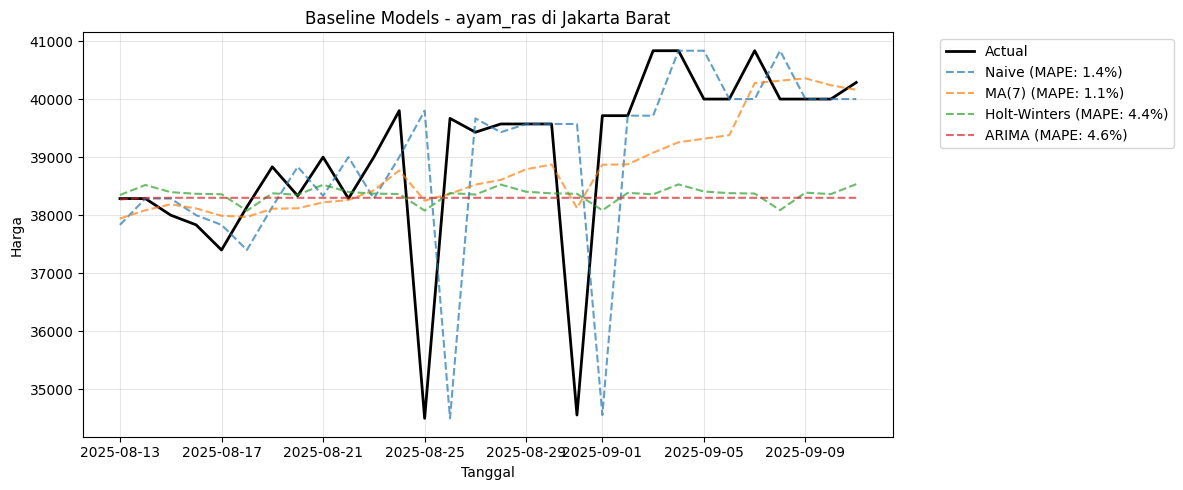

In [24]:
plt.figure(figsize=(12, 5))

# Plot actual vs prediksi (sample 30 hari test)
days_to_plot = min(30, len(test))
plt.plot(test['tanggal'].iloc[:days_to_plot],
         y_test[:days_to_plot],
         label='Actual', color='black', linewidth=2)

# Plot tiap model
plt.plot(test['tanggal'].iloc[:days_to_plot],
         y_pred_naive[:days_to_plot],
         '--', label=f'Naive (MAPE: {mape_naive:.1f}%)', alpha=0.7)

plt.plot(test['tanggal'].iloc[:days_to_plot],
         y_pred_ma7[:days_to_plot],
         '--', label=f'MA(7) (MAPE: {mape_ma7:.1f}%)', alpha=0.7)

if not np.isnan(mape_hw):
    plt.plot(test['tanggal'].iloc[:days_to_plot],
             y_pred_hw[:days_to_plot],
             '--', label=f'Holt-Winters (MAPE: {mape_hw:.1f}%)', alpha=0.7)

if not np.isnan(mape_arima):
    plt.plot(test['tanggal'].iloc[:days_to_plot],
             y_pred_arima[:days_to_plot],
             '--', label=f'ARIMA (MAPE: {mape_arima:.1f}%)', alpha=0.7)

plt.title(f'Baseline Models - {KOMODITAS} di {REGION}')
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Model: GRU

Prepare for GRU

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Pilih komoditas & region (sama seperti baseline)
KOMODITAS = 'ayam_ras'
REGION = 'Jakarta Barat'

# Filter data
df_gru = df_merged[(df_merged['komoditas'] == KOMODITAS) &
                   (df_merged['region'] == REGION)].copy()
df_gru = df_gru.sort_values('tanggal').reset_index(drop=True)
df_gru = df_gru.dropna().reset_index(drop=True)

print(f"✅ Data GRU: {len(df_gru)} hari")

✅ Data GRU: 701 hari


Feature for GRU

In [26]:
# Pilih fitur untuk input GRU
feature_cols = [
    'harga',                # target juga dipakai sebagai input (lag)
    'ump_daily',            # UMP sebagai variabel eksternal
    'harga_ma_7',           # moving average
    'harga_std_7',          # volatilitas
    'rasio_harga_ump',      # daya beli implisit
    'month',                # musiman
    'dayofweek',            # pola mingguan
    'is_weekend'            # akhir pekan
]

# Tambahkan lag features (1,2,3,7)
lag_cols = ['harga_lag_1', 'harga_lag_2', 'harga_lag_3', 'harga_lag_7']
feature_cols.extend(lag_cols)

print(f"📊 Fitur yang digunakan ({len(feature_cols)} kolom):")
print(feature_cols)

# Ambil data fitur
data = df_gru[feature_cols].values

📊 Fitur yang digunakan (12 kolom):
['harga', 'ump_daily', 'harga_ma_7', 'harga_std_7', 'rasio_harga_ump', 'month', 'dayofweek', 'is_weekend', 'harga_lag_1', 'harga_lag_2', 'harga_lag_3', 'harga_lag_7']


Normalisasi Data

In [27]:
# Normalisasi fitur (MinMaxScaler)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Pisahkan target (harga) dan fitur lainnya
# Target ada di kolom pertama ('harga')
target_scaled = data_scaled[:, 0].reshape(-1, 1)
features_scaled = data_scaled

print(f"✅ Data setelah normalisasi: {features_scaled.shape}")

✅ Data setelah normalisasi: (701, 12)


Sequence for GRU

In [28]:
def create_sequences(data, target, window_size=30, forecast_horizon=1):
    """
    window_size: berapa hari ke belakang untuk prediksi
    forecast_horizon: prediksi berapa hari ke depan
    """
    X, y = [], []
    for i in range(len(data) - window_size - forecast_horizon):
        X.append(data[i:i+window_size])
        y.append(target[i+window_size:i+window_size+forecast_horizon].mean())
    return np.array(X), np.array(y)

# Parameter
WINDOW_SIZE = 30          # pakai 30 hari terakhir
FORECAST_HORIZON = 1      # prediksi 1 hari ke depan

# Buat sequence
X, y = create_sequences(features_scaled, target_scaled,
                         WINDOW_SIZE, FORECAST_HORIZON)

print(f"✅ X shape: {X.shape} = [samples, timesteps, features]")
print(f"✅ y shape: {y.shape}")

✅ X shape: (670, 30, 12) = [samples, timesteps, features]
✅ y shape: (670,)


Split Train-Test (80-20)

In [29]:
# Split (harus berurutan, tidak acak!)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (536, 30, 12), Test: (134, 30, 12)


GRU Architecture

In [30]:
model = Sequential([
    # GRU layer 1 dengan return sequences (karena ada layer GRU lagi)
    GRU(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.2),

    # GRU layer 2
    GRU(32, return_sequences=False),
    Dropout(0.2),

    # Dense layer
    Dense(16, activation='relu'),
    Dense(1)
])

# Compile
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Ringkasan model
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 64)         │        14,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,929 (97.38 KB)

 Trainable params: 24,929 (97.38 KB)

 Non-trainable params: 0 (0.00 B)

Training GRU

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 218ms/step - loss: 0.0083 - mae: 0.0666 - val_loss: 8.2558e-05 - val_mae: 0.0060
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - loss: 0.0028 - mae: 0.0298 - val_loss: 1.7578e-04 - val_mae: 0.0115
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0047 - mae: 0.0271 - val_loss: 1.6347e-04 - val_mae: 0.0101
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0012 - mae: 0.0206 - val_loss: 1.2181e-04 - val_mae: 0.0091
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0026 - mae: 0.0196 - val_loss: 1.2927e-04 - val_mae: 0.0086
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0031 - mae: 0.0196 - val_loss: 7.5996e-05 - val_mae: 0.0053
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0025 - mae: 0.0166 - val_loss: 8.0752e-05 - val_mae: 0.0053
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 0.0028 - mae: 0.0156 - val_loss: 8.0594e-05 - val_mae: 0.0058
Epoch 9/100
16/16 ━━━

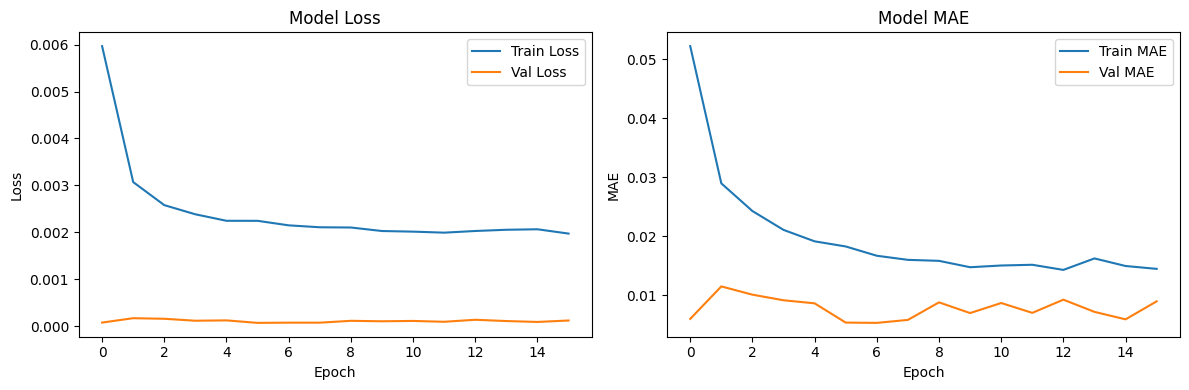

In [31]:
# Early stopping biar berhenti kalau loss tidak turun
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Training
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

Evaluasi GRU

In [32]:
# Prediksi
y_pred_scaled = model.predict(X_test)

# Inverse transform untuk dapat nilai asli
# Karena target adalah kolom pertama, kita perlu gabungkan dulu
y_test_full = np.zeros((len(y_test), features_scaled.shape[1]))
y_test_full[:, 0] = y_test.flatten()
y_test_actual = scaler.inverse_transform(y_test_full)[:, 0]

y_pred_full = np.zeros((len(y_pred_scaled), features_scaled.shape[1]))
y_pred_full[:, 0] = y_pred_scaled.flatten()
y_pred_actual = scaler.inverse_transform(y_pred_full)[:, 0]

# Hitung metrik
mae_gru = mean_absolute_error(y_test_actual, y_pred_actual)
rmse_gru = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mape_gru = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

print("\n📊 GRU MODEL PERFORMANCE:")
print(f"MAE: {mae_gru:.2f}")
print(f"RMSE: {rmse_gru:.2f}")
print(f"MAPE: {mape_gru:.2f}%")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step

📊 GRU MODEL PERFORMANCE:
MAE: 1377.74
RMSE: 1504.77
MAPE: 3.43%


Plot Hasil GRU vs Actual

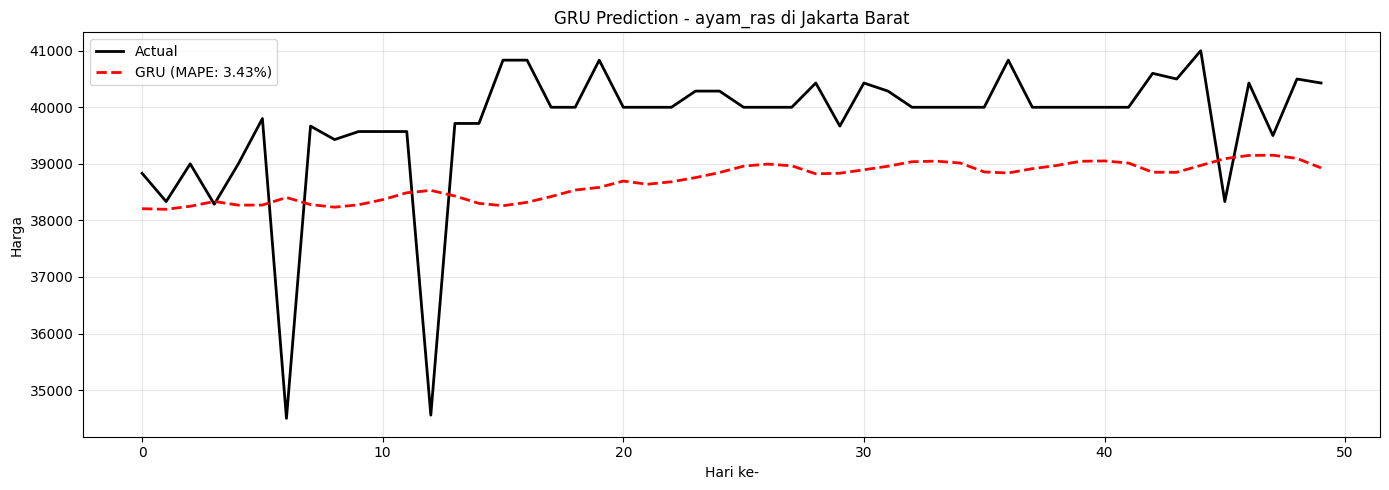

In [33]:
plt.figure(figsize=(14, 5))

# Plot 50 hari terakhir test
days_to_plot = min(50, len(y_test_actual))
x_axis = range(days_to_plot)

plt.plot(x_axis, y_test_actual[:days_to_plot],
         label='Actual', color='black', linewidth=2)
plt.plot(x_axis, y_pred_actual[:days_to_plot],
         label=f'GRU (MAPE: {mape_gru:.2f}%)',
         color='red', linestyle='--', linewidth=2)

plt.title(f'GRU Prediction - {KOMODITAS} di {REGION}')
plt.xlabel('Hari ke-')
plt.ylabel('Harga')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Compare with Baseline


📊 PERBANDINGAN SEMUA MODEL:
          Model  MAPE
0         Naive  1.40
1         MA(7)  1.10
2  Holt-Winters  4.40
3         ARIMA  4.60
4    GRU (Anda)  3.43


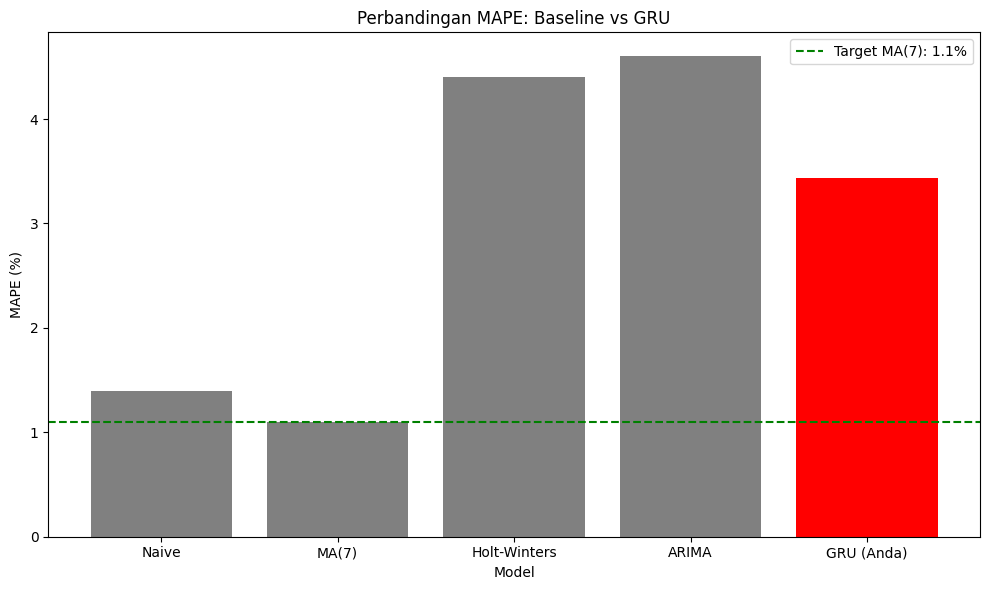


💪 GRU masih kalah dari MA(7). Coba tuning parameter.


In [34]:
# Gabungkan hasil baseline (dari step 5) dengan GRU
comparison = pd.DataFrame({
    'Model': ['Naive', 'MA(7)', 'Holt-Winters', 'ARIMA', 'GRU (Anda)'],
    'MAPE': [1.4, 1.1, 4.4, 4.6, mape_gru]
})

print("\n📊 PERBANDINGAN SEMUA MODEL:")
print(comparison.round(2))

# Plot perbandingan
plt.figure(figsize=(10, 6))
colors = ['gray', 'gray', 'gray', 'gray', 'red']
bars = plt.bar(comparison['Model'], comparison['MAPE'], color=colors)
plt.axhline(y=1.1, color='green', linestyle='--', label='Target MA(7): 1.1%')
plt.title('Perbandingan MAPE: Baseline vs GRU')
plt.xlabel('Model')
plt.ylabel('MAPE (%)')
plt.legend()
plt.tight_layout()
plt.show()

# Kesimpulan
if mape_gru < 1.1:
    print("\n🎉 SELAMAT! GRU Anda MENGALAHKAN MA(7)!")
else:
    print("\n💪 GRU masih kalah dari MA(7). Coba tuning parameter.")